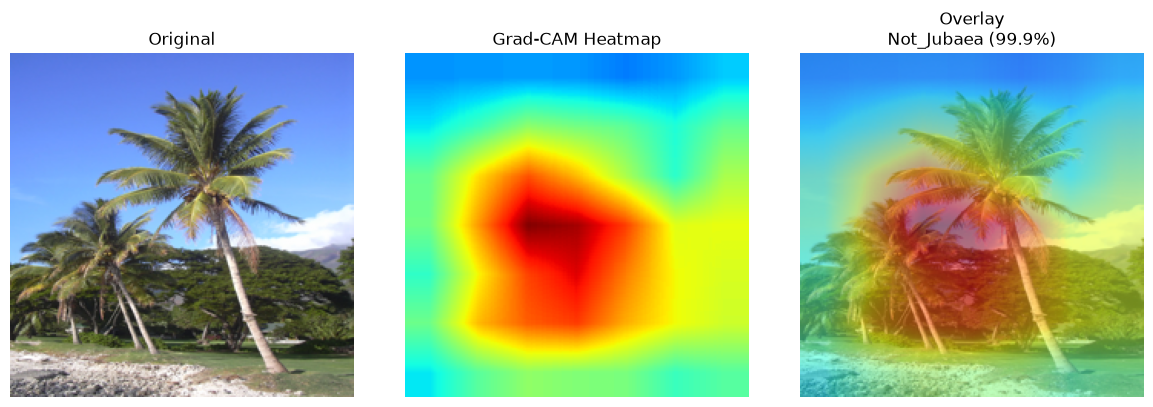

In [10]:
from torchvision import models, transforms
from grad_cam import GradCAM, show_gradcam

import torch

#GPU oder CPU
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

net = models.resnet18(weights=None)
net.load_state_dict(torch.load('Jubaea_with_val_resnet.pth', map_location=device))
net = net.to(device)
net.eval()

#Gleiche Transformationen wie beim trainieren
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


classes = ["Not_Jubaea","Jubaea"]

target_layer = net.layer4[-1]
gradcam = GradCAM(net, target_layer)

show_gradcam(
    model = gradcam,
    image_path = "Data/Not_Jubaea/Coconut_Palm/coco1.jpg",
    transform = test_transform,
    device = device,
    classes = classes,
    save_path= "example_3.jpg",
)